In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")
sns.set_theme()

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_cleaned.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_cleaned.csv")

category = pd.read_csv("../data/processed/category_inflows_cleaned.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_cleaned.csv")

holdings = pd.read_csv("../data/processed/portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


Task 1: NAV Trend Analysis

Prepare NAV Data

In [4]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (45962, 3)
Transactions: (32778, 13)
Performance: (40, 19)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [5]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-02  512.1124  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-03  503.1674  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-04  531.2850  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  474.1732  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  452.5840  HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme Name"
)

fig.show()

In [7]:
fig.write_html("../reports/nav_trend.html")

print("NAV Trend Chart Saved Successfully")

NAV Trend Chart Saved Successfully


### Insight 1

Most mutual fund schemes show a positive long-term NAV trend between 2022 and 2026, indicating overall market growth despite short-term fluctuations.

In [8]:
print(aum.columns)

print("\n")

print(aum.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


## Task 2: AUM Growth Analysis

### AUM Growth by Fund House (2022–2025)

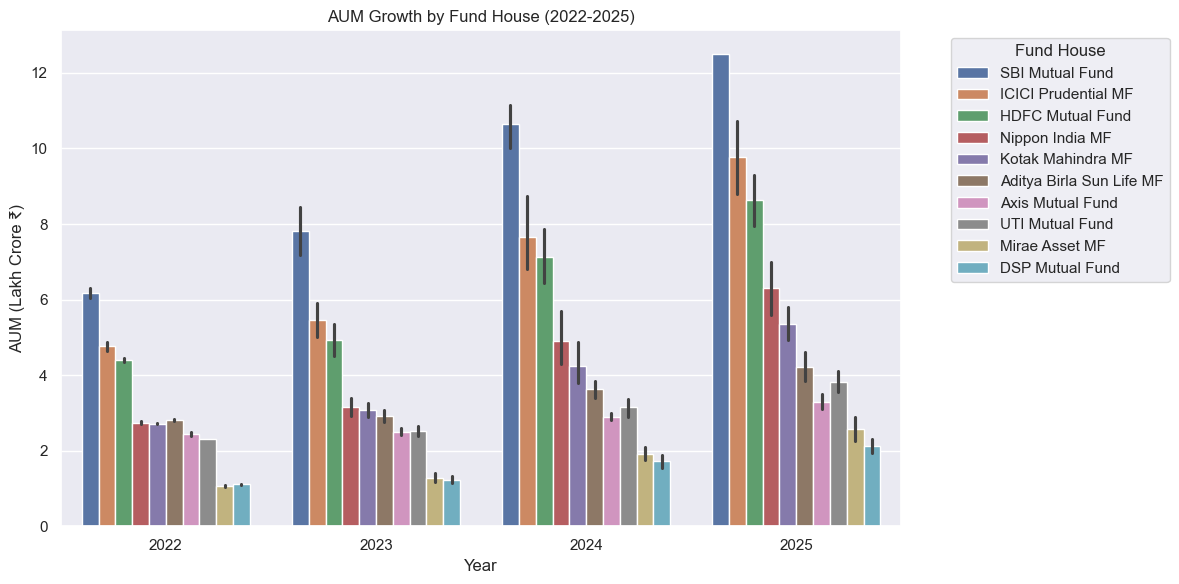

In [ ]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()

# Save chart
plt.savefig("../reports/aum_growth.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 2

SBI Mutual Fund maintained the highest Assets Under Management (AUM) throughout 2022–2025, reaching approximately ₹12.5 lakh crore in 2025 and demonstrating strong market leadership.

**Chart Reference:** AUM Growth by Fund House (2022–2025)

# Task 3: SIP Inflow Time-Series (2022–2025)

In [18]:
sip["month"] = pd.to_datetime(sip["month"])

import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

# Highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [20]:
fig.write_html("../reports/sip_inflow_trend.html")

print("SIP Trend Chart Saved")

SIP Trend Chart Saved


## Insight 3

SIP inflows increased steadily from 2022 to 2025, indicating growing retail investor participation in mutual funds. The highest monthly SIP inflow was recorded in December 2025 at approximately ₹31,002 crore.

**Chart Reference:** Monthly SIP Inflow Trend (2022–2025)

## Task 4: Category Inflow Heatmap

This analysis shows category-wise monthly net inflows across different mutual fund categories. Higher color intensity represents stronger investor inflows.

In [23]:
print(category.columns)

print("\n")

print(category.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


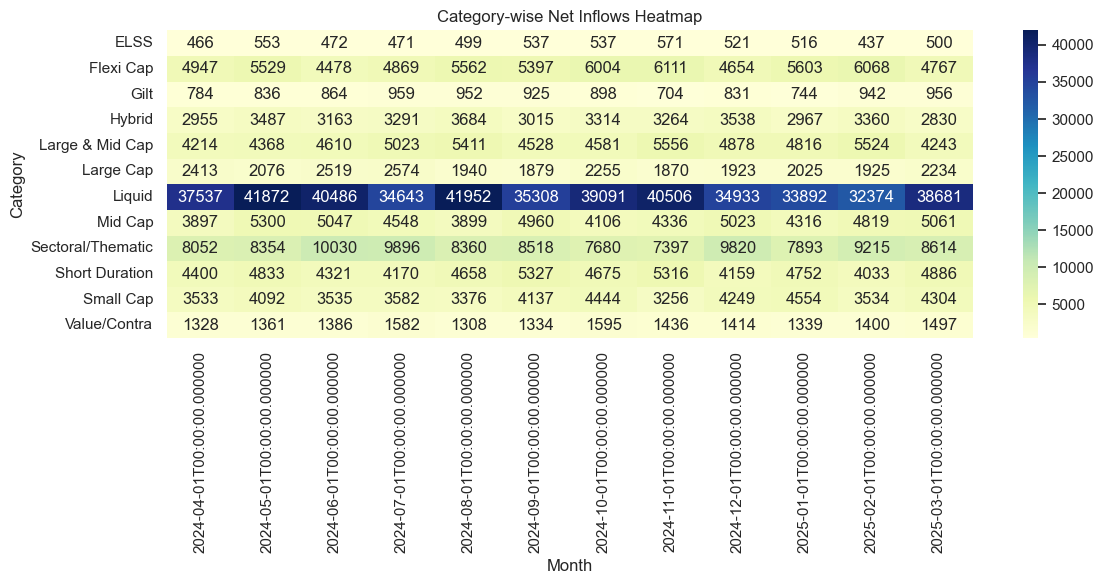

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert month column
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig("../reports/category_heatmap.png", dpi=300)

plt.show()